# Лекция 6: Базови модели и данни за предварително обучение

Тази тетрадка съдържа демонстрациите към Лекция 6. Презентационната част е в слайдовете (`lecture_06_slides.md`).

## Преговор от Лекция 5

В Лекция 5 разгледахме:
- Трите трансформатор архитектури: encoder-only, decoder-only, encoder-decoder
- Пълния трансформаторен блок и неговите компоненти
- Позиционно кодиране: синусоидално, обучаеми вграждания, RoPE
- nanoGPT върху корпуса на Вазов

Два компонента останаха: **активационни функции** и **нормализация на слоя**. Започваме с тях.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import hashlib

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print('Библиотеките са заредени.')

Device: cpu
Библиотеките са заредени.


---

## Част 1: Довършване от Лекция 5

### Активационни функции

#### От sigmoid и tanh до ReLU

Припомняме от Лекция 2: sigmoid и tanh **наситяват** при големи $|x|$ -- градиентът клони към 0.

**ReLU** $\text{max}(0, x)$ -- пробивът: проста, бърза, не наситява за $x > 0$. Но ако $x < 0$, градиентът е точно 0 -- проблем с "умиращите неврони".

In [2]:
x = torch.linspace(-4, 4, 500)

sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
relu = F.relu(x)

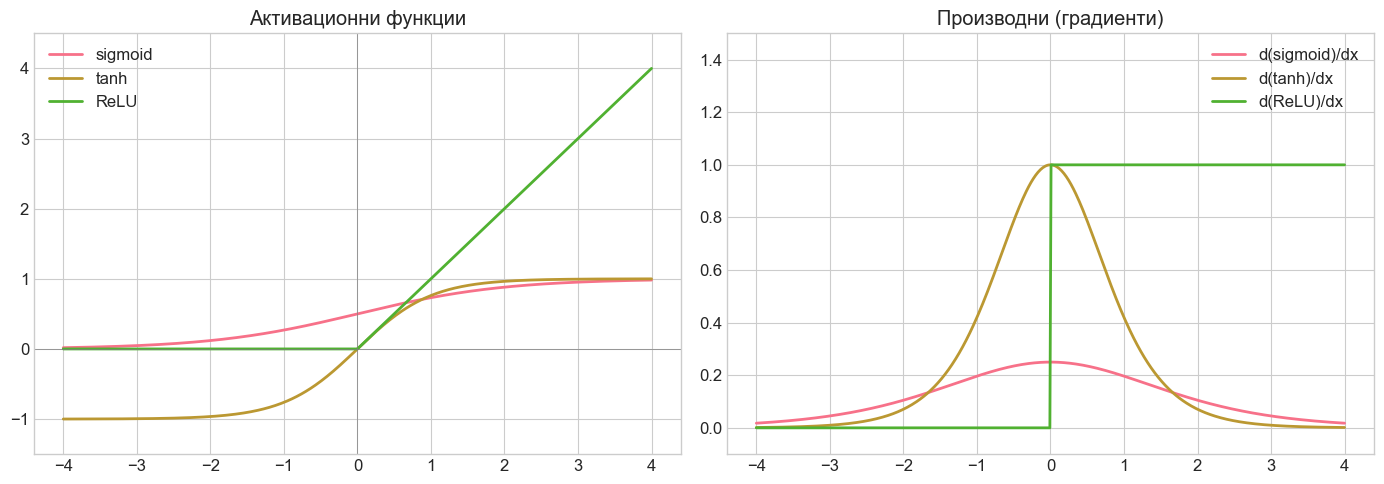

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Функции
axes[0].plot(x, sigmoid, label='sigmoid', linewidth=2)
axes[0].plot(x, tanh, label='tanh', linewidth=2)
axes[0].plot(x, relu, label='ReLU', linewidth=2)
axes[0].axhline(y=0, color='gray', linewidth=0.5)
axes[0].axvline(x=0, color='gray', linewidth=0.5)
axes[0].set_title('Активационни функции')
axes[0].legend()
axes[0].set_ylim(-1.5, 4.5)

# Производни
for fn, name in [(torch.sigmoid, 'sigmoid'), (torch.tanh, 'tanh'), (F.relu, 'ReLU')]:
    x_g = x.clone().requires_grad_(True)
    y = fn(x_g)
    grad = torch.autograd.grad(y.sum(), x_g)[0]
    axes[1].plot(x.detach(), grad.detach(), label=f'd({name})/dx', linewidth=2)

axes[1].set_title('Производни (градиенти)')
axes[1].legend()
axes[1].set_ylim(-0.1, 1.5)

plt.tight_layout()
plt.show()

sigmoid и tanh имат градиент ~ 0 при големи $|x|$. ReLU запазва градиент = 1 за $x > 0$, но е точно 0 за $x < 0$.

#### Нелинейности в трансформаторите

**GELU** (Gaussian Error Linear Unit): $x \cdot \Phi(x)$, където $\Phi$ е CDF на нормалното разпределение. Използва се в GPT-2 и BERT.

**SwiGLU**: вариант с gating механизъм, базиран на SiLU/Swish ($x \cdot \sigma(x)$). Използва се в LLaMA, Mistral, Gemma.

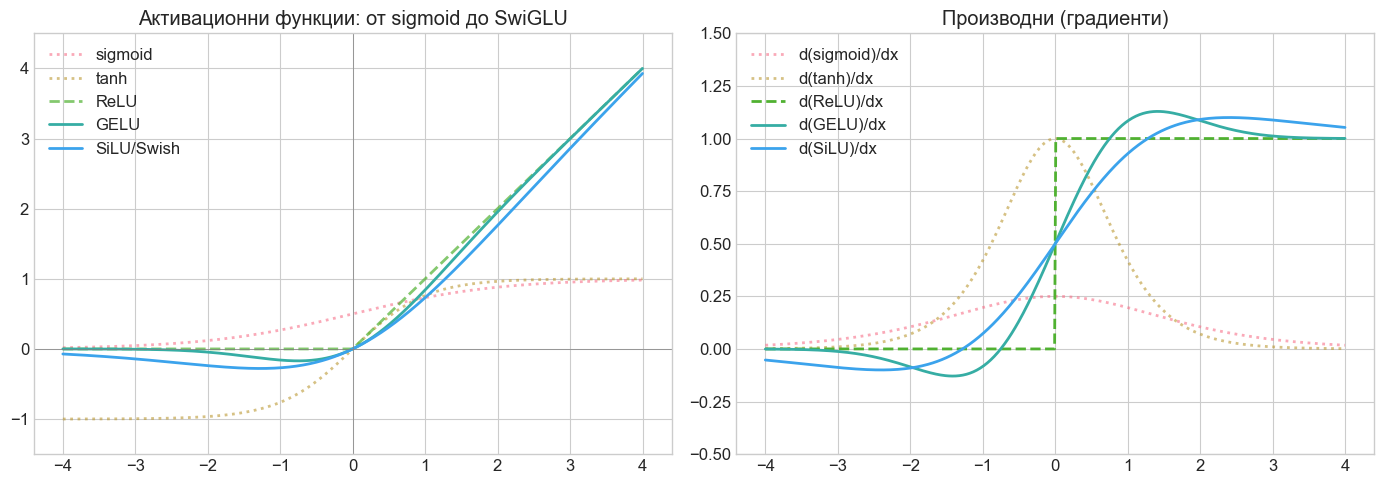

In [4]:
gelu = F.gelu(x)
silu = F.silu(x)  # SiLU/Swish -- основата на SwiGLU

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Всички 5 функции
axes[0].plot(x, sigmoid, label='sigmoid', linewidth=2, linestyle=':', alpha=0.6)
axes[0].plot(x, tanh, label='tanh', linewidth=2, linestyle=':', alpha=0.6)
axes[0].plot(x, relu, label='ReLU', linewidth=2, linestyle='--', alpha=0.7)
axes[0].plot(x, gelu, label='GELU', linewidth=2)
axes[0].plot(x, silu, label='SiLU/Swish', linewidth=2)
axes[0].axhline(y=0, color='gray', linewidth=0.5)
axes[0].axvline(x=0, color='gray', linewidth=0.5)
axes[0].set_title('Активационни функции: от sigmoid до SwiGLU')
axes[0].legend()
axes[0].set_ylim(-1.5, 4.5)

# Производни на всички 5
for fn, name in [(torch.sigmoid, 'sigmoid'), (torch.tanh, 'tanh'),
                  (F.relu, 'ReLU'), (F.gelu, 'GELU'), (F.silu, 'SiLU')]:
    x_g = x.clone().requires_grad_(True)
    y = fn(x_g)
    grad = torch.autograd.grad(y.sum(), x_g)[0]
    style = ':' if name in ('sigmoid', 'tanh') else ('--' if name == 'ReLU' else '-')
    alpha = 0.6 if name in ('sigmoid', 'tanh') else 1.0
    axes[1].plot(x.detach(), grad.detach(), label=f'd({name})/dx',
                 linewidth=2, linestyle=style, alpha=alpha)

axes[1].set_title('Производни (градиенти)')
axes[1].legend()
axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

GELU и SiLU/Swish са плавни -- не прекъсват рязко при $x = 0$ като ReLU. По-гладката функция дава по-стабилни градиенти в дълбоки мрежи.

Хронология: sigmoid/tanh (исторически) -> ReLU (пробив) -> GELU (GPT-2/BERT) -> SwiGLU (LLaMA/Mistral).

По-нататък в лекцията ще видим SwiGLU в реалната LLaMA архитектура.

### Нормализация на слоя (Layer Normalization)

Нормализира активациите по последното измерение: средно -> 0, стандартно отклонение -> 1.

$$\text{LayerNorm}(x) = \frac{x - \mu}{\sigma + \epsilon} \cdot \gamma + \beta$$

In [5]:
# LayerNorm на ръка vs nn.LayerNorm
x_demo = torch.tensor([[3.0, -1.0, 2.0, 5.0]])

# На ръка
mu = x_demo.mean(dim=-1, keepdim=True)
sigma = x_demo.std(dim=-1, keepdim=True, unbiased=False)
x_norm_manual = (x_demo - mu) / (sigma + 1e-5)

# С nn.LayerNorm
ln = nn.LayerNorm(4, elementwise_affine=False)
x_norm_torch = ln(x_demo)

print(f'Вход:              {x_demo.squeeze().tolist()}')
print(f'Средно:            {mu.item():.2f}')
print(f'Стд. отклонение:   {sigma.item():.2f}')
print(f'На ръка:           {[f"{v:.4f}" for v in x_norm_manual.squeeze().tolist()]}')
print(f'nn.LayerNorm:      {[f"{v:.4f}" for v in x_norm_torch.detach().squeeze().tolist()]}')
print(f'\nСлед нормализация: средно = {x_norm_torch.mean().item():.4f}, стд. откл. = {x_norm_torch.std(unbiased=False).item():.4f}')

Вход:              [3.0, -1.0, 2.0, 5.0]
Средно:            2.25
Стд. отклонение:   2.17
На ръка:           ['0.3464', '-1.5011', '-0.1155', '1.2702']
nn.LayerNorm:      ['0.3464', '-1.5011', '-0.1155', '1.2702']

След нормализация: средно = 0.0000, стд. откл. = 1.0000


**Pre-norm vs Post-norm:**
- **Post-norm** (оригиналният Transformer): LayerNorm *след* подслоя -- по-труден за обучение
- **Pre-norm** (GPT-2, съвременни модели): LayerNorm *преди* подслоя -- по-стабилен

**RMSNorm** -- опростен вариант без центриране (без изваждане на средното). Използва се в LLaMA.

In [6]:
# RMSNorm на ръка
def rms_norm(x, eps=1e-6):
    rms = torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + eps)
    return x / rms

x_rms = rms_norm(x_demo)
print(f'Вход:        {x_demo.squeeze().tolist()}')
print(f'LayerNorm:   {[f"{v:.4f}" for v in x_norm_manual.squeeze().tolist()]}')
print(f'RMSNorm:     {[f"{v:.4f}" for v in x_rms.squeeze().tolist()]}')
print(f'\nРазликата: RMSNorm не центрира (не вади средното), само скалира.')

Вход:        [3.0, -1.0, 2.0, 5.0]
LayerNorm:   ['0.3464', '-1.5011', '-0.1155', '1.2702']
RMSNorm:     ['0.9608', '-0.3203', '0.6405', '1.6013']

Разликата: RMSNorm не центрира (не вади средното), само скалира.


### Мрежа с пряко предаване (FFN) и остатъчни връзки

**FFN**: Linear -> GELU -> Linear. Размерност: $d_{model}$ -> $4 \cdot d_{model}$ -> $d_{model}$.

Вниманието (attention) смесва информация *между* позиции. FFN трансформира информация *на* всяка позиция поотделно.

In [7]:
# Колко параметри заема FFN в GPT-2?
d = 768  # d_model на GPT-2
ffn_params = d * 4*d + 4*d + 4*d * d + d  # W1, b1, W2, b2
total_params = 124_000_000  # GPT-2 small

print(f'FFN параметри на блок: {ffn_params:,} ({ffn_params/1e6:.1f}M)')
print(f'FFN дял от целия модел: ~{12 * ffn_params / total_params:.0%} (12 блока)')
print(f'\nПовечето параметри на трансформатора са в FFN слоевете!')

FFN параметри на блок: 4,722,432 (4.7M)
FFN дял от целия модел: ~46% (12 блока)

Повечето параметри на трансформатора са в FFN слоевете!


**Остатъчни връзки (Residual Connections):** $\text{output} = x + \text{sublayer}(x)$

Градиентът може да "прескочи" слоя по identity пътя -- решава проблема с изчезващия градиент в дълбоки мрежи.

In [8]:
depth = 12
dim = 64

def measure_gradients(use_residual):
    torch.manual_seed(0)
    layers = [nn.Linear(dim, dim) for _ in range(depth)]
    x = torch.randn(1, dim, requires_grad=True)
    h = x
    for layer in layers:
        if use_residual:
            h = h + F.gelu(layer(h))
        else:
            h = F.gelu(layer(h))
    loss = h.sum()
    loss.backward()
    return x.grad.norm().item()

grad_no_res = measure_gradients(use_residual=False)
grad_with_res = measure_gradients(use_residual=True)

print(f'Без остатъчни връзки: ||grad|| = {grad_no_res:.6f}')
print(f'С остатъчни връзки:   ||grad|| = {grad_with_res:.6f}')
print(f'Разлика:              {grad_with_res / max(grad_no_res, 1e-10):.1f}x')

Без остатъчни връзки: ||grad|| = 0.000006
С остатъчни връзки:   ||grad|| = 78.442101
Разлика:              13637875.1x


### Обобщение: пълният трансформаторен блок

$$x \rightarrow \text{LN} \rightarrow \text{MHA} \rightarrow +x \rightarrow \text{LN} \rightarrow \text{FFN(GELU)} \rightarrow +x$$

Сега знаем всеки компонент. Преминаваме към *как* и *върху какво* се обучават тези модели.

**-> Слайдове: Transfer learning, BERT, обучителни задачи**

---

## Част 2: Демонстрации -- BERT и архитектурна еволюция

*Продължаваме след слайдовете за transfer learning и обучителни задачи.*

### BERT: маскирано езиково моделиране на практика

Видяхме на слайдовете, че BERT се обучава с маскирано езиково моделиране (MLM): скрий токен, предвиди го от контекста. Нека видим на живо.

In [9]:
from transformers import pipeline

fill_mask = pipeline('fill-mask', model='bert-base-uncased')
print('BERT (base-uncased) зареден.')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT (base-uncased) зареден.


In [10]:
results = fill_mask('The capital of France is [MASK].')

print('Подкана: "The capital of France is [MASK]."\n')
for r in results:
    print(f'  {r["token_str"]:>12s}  (вероятност: {r["score"]:.3f})')

Подкана: "The capital of France is [MASK]."

         paris  (вероятност: 0.417)
         lille  (вероятност: 0.071)
          lyon  (вероятност: 0.063)
     marseille  (вероятност: 0.044)
         tours  (вероятност: 0.030)


BERT вижда контекст от **двете** страни на маската -- думите преди *и след* `[MASK]` влияят на предсказанието.

In [11]:
# Bidirectional контекст: думите СЛЕД маската променят предсказанието
examples = [
    'The [MASK] chased the mouse around the house.',
    'The [MASK] chased the criminal through the city.',
    'She went to the [MASK] to buy some groceries.',
    'She went to the [MASK] to watch a movie.',
]

for text in examples:
    preds = fill_mask(text)
    top3 = ', '.join(f'{p["token_str"]}({p["score"]:.2f})' for p in preds[:3])
    print(f'{text}')
    print(f'  -> {top3}\n')

The [MASK] chased the mouse around the house.
  -> cat(0.26), dog(0.17), man(0.03)

The [MASK] chased the criminal through the city.
  -> police(0.36), mob(0.03), gang(0.03)

She went to the [MASK] to buy some groceries.
  -> store(0.79), supermarket(0.05), market(0.03)

She went to the [MASK] to watch a movie.
  -> bathroom(0.11), theater(0.10), cinema(0.10)



Думите **след** маската променят предсказанието: "chased the mouse" -> cat, "chased the criminal" -> police. Decoder моделът (GPT) не може да направи това -- той вижда само контекст отляво.

In [12]:
# Multilingual BERT на български
fill_mask_multi = pipeline('fill-mask', model='bert-base-multilingual-cased')
print('Multilingual BERT зареден.')

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-multilingual-cased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Multilingual BERT зареден.


In [13]:
bg_examples = [
    'София е столицата на [MASK].',
    'Иван Вазов е написал [MASK].',
    'Ученикът отиде на [MASK] да учи.',
]

for text in bg_examples:
    preds = fill_mask_multi(text)
    top3 = ', '.join(f'{p["token_str"]}({p["score"]:.2f})' for p in preds[:3])
    print(f'{text}')
    print(f'  -> {top3}\n')

София е столицата на [MASK].
  -> София(0.41), България(0.22), св(0.03)

Иван Вазов е написал [MASK].
  -> о(0.07), п(0.05), св(0.03)

Ученикът отиде на [MASK] да учи.
  -> място(0.06), училище(0.05), него(0.04)



Multilingual BERT знае нещо на български, но качеството е по-ниско -- малка част от обучителните данни са на български. Ще видим защо в Част 3.

### GPT-2 vs LLaMA: архитектурна еволюция

И двата модела са decoder-only, но на 5 години разстояние. Нека сравним какво се е променило.

In [14]:
from transformers import AutoModel, AutoConfig

gpt2 = AutoModel.from_pretrained('gpt2')
print('GPT-2 (124M) зареден.')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 (124M) зареден.


In [15]:
print('=' * 60)
print('GPT-2 (2019) -- архитектура')
print('=' * 60)
print(gpt2)

GPT-2 (2019) -- архитектура
GPT2Model(
  (wte): Embedding(50257, 768)
  (wpe): Embedding(1024, 768)
  (drop): Dropout(p=0.1, inplace=False)
  (h): ModuleList(
    (0-11): 12 x GPT2Block(
      (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (attn): GPT2Attention(
        (c_attn): Conv1D(nf=2304, nx=768)
        (c_proj): Conv1D(nf=768, nx=768)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (mlp): GPT2MLP(
        (c_fc): Conv1D(nf=3072, nx=768)
        (c_proj): Conv1D(nf=768, nx=3072)
        (act): NewGELUActivation()
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [19]:
# LLaMA -- зареждаме само конфигурацията и инстанцираме без тегла
llama_config = AutoConfig.from_pretrained('unsloth/Llama-3.2-1B')
llama = AutoModel.from_config(llama_config)
print(f'LLaMA 3.2 1B -- модел инстанциран ({sum(p.numel() for p in llama.parameters())/1e6:.0f}M параметъра).')

config.json:   0%|          | 0.00/889 [00:00<?, ?B/s]

LLaMA 3.2 1B -- модел инстанциран (1236M параметъра).


In [23]:
print('=' * 60)
print('LLaMA 3.2 1B (2024) -- архитектура')
print('=' * 60)
print(llama)

LLaMA 3.2 1B (2024) -- архитектура
LlamaModel(
  (embed_tokens): Embedding(128256, 2048, padding_idx=128004)
  (layers): ModuleList(
    (0-15): 16 x LlamaDecoderLayer(
      (self_attn): LlamaAttention(
        (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
        (k_proj): Linear(in_features=2048, out_features=512, bias=False)
        (v_proj): Linear(in_features=2048, out_features=512, bias=False)
        (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
      )
      (mlp): LlamaMLP(
        (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
        (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
        (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
        (act_fn): SiLUActivation()
      )
      (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
    )
  )
  (norm): LlamaRMSNorm((2048,), eps=1e-05)
  (rotary_emb): Llama

Нека извлечем ключовите разлики систематично.

In [24]:
# Първи блок от GPT-2
print('GPT-2 -- един трансформаторен блок:')
print(gpt2.h[0])

GPT-2 -- един трансформаторен блок:
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


In [25]:
# Първи блок от LLaMA
print('LLaMA -- един трансформаторен блок:')
print(llama.layers[0])

LLaMA -- един трансформаторен блок:
LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
    (k_proj): Linear(in_features=2048, out_features=512, bias=False)
    (v_proj): Linear(in_features=2048, out_features=512, bias=False)
    (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
    (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
)


In [26]:
gpt2_config = gpt2.config

def count_params(model):
    return sum(p.numel() for p in model.parameters())

comparison = {
    'Година': ['2019', '2024'],
    'Параметри': [f'{count_params(gpt2)/1e6:.0f}M', f'{count_params(llama)/1e6:.0f}M'],
    'Слоеве': [gpt2_config.n_layer, llama_config.num_hidden_layers],
    'd_model': [gpt2_config.n_embd, llama_config.hidden_size],
    'Attention глави': [gpt2_config.n_head, llama_config.num_attention_heads],
    'KV глави': [gpt2_config.n_head, llama_config.num_key_value_heads],
    'Normalization': ['LayerNorm', 'RMSNorm'],
    'Activation (FFN)': [gpt2_config.activation_function, llama_config.hidden_act],
    'Positional': ['Learned embeddings', 'RoPE'],
    'Attention тип': ['MHA', f'GQA ({llama_config.num_key_value_heads} KV групи)'],
    'Vocab size': [gpt2_config.vocab_size, llama_config.vocab_size],
}

print(f'{"":>20s}  {"GPT-2":>20s}  {"LLaMA 3.2 1B":>20s}')
print('-' * 64)
for key, (v1, v2) in comparison.items():
    print(f'{key:>20s}  {str(v1):>20s}  {str(v2):>20s}')

                                     GPT-2          LLaMA 3.2 1B
----------------------------------------------------------------
              Година                  2019                  2024
           Параметри                  124M                 1236M
              Слоеве                    12                    16
             d_model                   768                  2048
     Attention глави                    12                    32
            KV глави                    12                     8
       Normalization             LayerNorm               RMSNorm
    Activation (FFN)              gelu_new                  silu
          Positional    Learned embeddings                  RoPE
       Attention тип                   MHA      GQA (8 KV групи)
          Vocab size                 50257                128256


Основни промени за 5 години:

| Компонент | GPT-2 (2019) | LLaMA (2024) |
|-----------|-------------|-------------|
| Normalization | LayerNorm | **RMSNorm** -- по-прост, без центриране |
| Activation | GELU | **SwiGLU** -- gating механизъм |
| Positional | Learned embeddings | **RoPE** -- относителна позиция |
| Attention | MHA (всяка глава има K, V) | **GQA** -- споделени K/V групи |

Всеки от тези компоненти видяхме в Част 1 и в Лекция 5. Архитектурата е само една част от историята -- другата е **данните**.

**-> Слайдове: Данни за предварително обучение, качество, contamination**

---

## Част 3: MinHash -- дедупликация на практика

*Продължаваме след слайдовете за данни, филтриране и дедупликация.*

На слайдовете видяхме, че дедупликацията е критична стъпка в подготовката на данни за обучение. MinHash + LSH е стандартният метод. Нека го имплементираме стъпка по стъпка.

### Стъпка 1: Текст -> множество от n-грами

Представяме всеки документ като множество от символни n-грами (shingles).

In [27]:
def get_shingles(text, n=5):
    """Extract character n-grams (shingles) from text."""
    text = text.lower().strip()
    return set(text[i:i+n] for i in range(len(text) - n + 1))

text_a = 'Иван Вазов е роден на 9 юли 1850 г. в град Сопот.'
shingles_a = get_shingles(text_a)

print(f'Текст: {text_a}')
print(f'Брой 5-грами: {len(shingles_a)}')
print(f'Примери: {list(shingles_a)[:8]}')

Текст: Иван Вазов е роден на 9 юли 1850 г. в град Сопот.
Брой 5-грами: 45
Примери: ['опот.', 'в гра', ' роде', ' град', 'н ваз', ' 9 юл', ' юли ', 'г. в ']


### Стъпка 2: Jaccard similarity

Сходството между две множества: $J(A, B) = \frac{|A \cap B|}{|A \cup B|}$

In [28]:
def jaccard(set_a, set_b):
    """Exact Jaccard similarity."""
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0

# Три документа: оригинал, леко променен, напълно различен
docs = {
    'Оригинал':  'Иван Вазов е роден на 9 юли 1850 г. в град Сопот.',
    'Промяна':   'Иван Вазов е роден на 9 юли 1850 година в град Сопот.',
    'Различен':  'Машинното самообучение е клон на изкуствения интелект.',
}

shingles = {name: get_shingles(text) for name, text in docs.items()}

print('Jaccard similarity (точна):')
names = list(docs.keys())
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        sim = jaccard(shingles[names[i]], shingles[names[j]])
        print(f'  {names[i]:>10s} <-> {names[j]:<10s}: {sim:.3f}')

Jaccard similarity (точна):
    Оригинал <-> Промяна   : 0.741
    Оригинал <-> Различен  : 0.011
     Промяна <-> Различен  : 0.010


Леко промененият текст има висока Jaccard similarity с оригинала. Exact hash (MD5/SHA-256) би ги третирал като напълно различни. Затова е нужна **fuzzy** дедупликация.

Проблемът: изчисляването на Jaccard за всяка двойка документи е $O(n^2)$ -- непрактично при трилиони документи.

### Стъпка 3: MinHash -- ефективна апроксимация

Идея: вместо да пазим цялото множество от n-грами, генерираме кратък **signature** (подпис) с $k$ hash функции. Всяка hash функция избира минималния елемент.

Ключово свойство: $P[\min(h(A)) = \min(h(B))] = J(A, B)$

In [29]:
def make_hash_fn(seed):
    """Create a hash function from a seed."""
    def hash_fn(shingle):
        return int(hashlib.md5(f'{seed}_{shingle}'.encode()).hexdigest(), 16)
    return hash_fn

def minhash_signature(shingle_set, num_hashes=128):
    """Compute MinHash signature for a set of shingles."""
    signature = []
    for i in range(num_hashes):
        hash_fn = make_hash_fn(i)
        min_hash = min(hash_fn(s) for s in shingle_set)
        signature.append(min_hash)
    return signature

print('MinHash функции -- дефинирани.')

MinHash функции -- дефинирани.


In [30]:
# Изчисляваме MinHash signatures
signatures = {name: minhash_signature(s) for name, s in shingles.items()}

# Апроксимирана Jaccard similarity от MinHash
def minhash_jaccard(sig_a, sig_b):
    """Estimate Jaccard similarity from MinHash signatures."""
    matches = sum(a == b for a, b in zip(sig_a, sig_b))
    return matches / len(sig_a)

print('Jaccard similarity:')
print(f'{"":>12s}  {"Точна":>8s}  {"MinHash":>8s}')
print('-' * 34)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        exact = jaccard(shingles[names[i]], shingles[names[j]])
        approx = minhash_jaccard(signatures[names[i]], signatures[names[j]])
        label = f'{names[i][:5]}<->{names[j][:5]}'
        print(f'{label:>12s}  {exact:>8.3f}  {approx:>8.3f}')

Jaccard similarity:
                 Точна   MinHash
----------------------------------
Ориги<->Промя     0.741     0.734
Ориги<->Разли     0.011     0.000
Промя<->Разли     0.010     0.000


MinHash апроксимира добре точната Jaccard similarity, но е **много по-ефективен**: сравняваме два кратки вектора вместо две множества.

С повече hash функции -> по-точна апроксимация.

In [31]:
# Как точността расте с броя hash функции
hash_counts = [8, 16, 32, 64, 128, 256]
exact_sim = jaccard(shingles['Оригинал'], shingles['Промяна'])

print(f'Точна Jaccard (Оригинал <-> Промяна): {exact_sim:.3f}\n')
print(f'{"Брой hash":>12s}  {"MinHash":>8s}  {"Грешка":>8s}')
print('-' * 34)

for k in hash_counts:
    sig_a = minhash_signature(shingles['Оригинал'], num_hashes=k)
    sig_b = minhash_signature(shingles['Промяна'], num_hashes=k)
    approx = minhash_jaccard(sig_a, sig_b)
    print(f'{k:>12d}  {approx:>8.3f}  {abs(approx - exact_sim):>8.3f}')

Точна Jaccard (Оригинал <-> Промяна): 0.741

   Брой hash   MinHash    Грешка
----------------------------------
           8     0.750     0.009
          16     0.812     0.072
          32     0.844     0.103
          64     0.766     0.025
         128     0.734     0.006
         256     0.734     0.006


### Дедупликация с праг

При LLaMA: 5-gram MinHash, Jaccard threshold 0.8 -- документи с $J > 0.8$ се считат за дубликати.

За трилиони документи MinHash + **LSH** (Locality-Sensitive Hashing) групира сходните документи в кофи (buckets), без да сравнява всички двойки.

In [32]:
# Симулация: дедупликация с праг
threshold = 0.8

more_docs = {
    'doc1': 'Иван Вазов е роден на 9 юли 1850 г. в град Сопот.',
    'doc2': 'Иван Вазов е роден на 9 юли 1850 година в град Сопот.',
    'doc3': 'Иван Вазов е роден на девети юли 1850 г. в гр. Сопот.',
    'doc4': 'Машинното самообучение е клон на изкуствения интелект.',
    'doc5': 'Иван Вазов е роден на 9 юли 1850 г. в Сопот, България.',
}

sigs = {}
for name, text in more_docs.items():
    sigs[name] = minhash_signature(get_shingles(text), num_hashes=128)

print(f'Дедупликация с праг Jaccard > {threshold}:\n')
kept = set(more_docs.keys())
removed = []

doc_names = list(more_docs.keys())
for i in range(len(doc_names)):
    if doc_names[i] not in kept:
        continue
    for j in range(i + 1, len(doc_names)):
        if doc_names[j] not in kept:
            continue
        sim = minhash_jaccard(sigs[doc_names[i]], sigs[doc_names[j]])
        if sim > threshold:
            kept.discard(doc_names[j])
            removed.append((doc_names[j], doc_names[i], sim))

for name, dup_of, sim in removed:
    print(f'  X {name} премахнат (дубликат на {dup_of}, Jaccard={sim:.2f})')
    print(f'    "{more_docs[name][:60]}..."')

print(f'\nЗапазени: {sorted(kept)}')
print(f'Премахнати: {len(removed)} от {len(more_docs)} документа')

Дедупликация с праг Jaccard > 0.8:


Запазени: ['doc1', 'doc2', 'doc3', 'doc4', 'doc5']
Премахнати: 0 от 5 документа


Без fuzzy дедупликация, леко различните варианти на един и същ текст биха останали в обучителните данни -- моделът би ги запаметил буквално вместо да генерализира.